# Dev / test notebook for adapting DEAR codebase


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import logging
import torch 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

sys.path.append('..')

import src.data_utils as dut
import src.plotting as splo

import src.dear.utils as sdu
import src.dear.data as sdd
from src.dear.model import BGM, BigJointDiscriminator

## Set up namespace, e.g. point to data

In [4]:
data_path = '../data/xView_0_fix/'
res_path = '../results/xView_0_fix/bcr_linscm_supce_pretr_norm_flips_res64_batch256_seed51/'

In [5]:
to_di = lambda x: dict( [y.split(':') for y in x.split('\t')[-1].split(',')])

rename_di = {
    'D loss' : 'disc',
    ' Encoder loss' : 'enc',
    ' Decoder loss' : 'dec',
    ' Sup loss' : 'sup',
    ' E_score' : 'enc_',
    ' D score' : 'dec_'
}

def parse_log( log_path):
    log_lines = dut.to_from_text( log_path).split('\n')
    df = pd.DataFrame([to_di(y) for y in log_lines[:-1]]).astype(float)
    df.rename( columns= rename_di, inplace= True)
    return df

In [6]:
# map names of the causal nodes to the index of the column in label.csv file
labels_index_di = {
    'buildings': 2,
    'roads': 3,
    'cars': 4,
}
labels_ordered = ['buildings','roads','cars']
# provide the causal structure as tuples of (parent,child)
causal_ordering = [
    ('buildings','roads'),
    ('roads','cars'),
    ('buildings','cars')
]

def adjacency_from_tuples( causal_ordering, labels_ordered):
    """
    NOTE: this returns the *transpose* of adjacency matrix, as this is what the DEAR framework 
    uses as input format; they refer to it as A, but typical causal notation is A_T, hence our notation.
    """
    n_nodes = len( labels_ordered)
    labels_enum_di =  dict(zip( labels_ordered, range( n_nodes)))
    A_T = torch.zeros( (n_nodes, n_nodes))
    for parent, child in causal_ordering:
        parent_id, child_id = labels_enum_di[ parent], labels_enum_di[ child]
        A_T[ parent_id, child_id] = 1
    return A_T

adjacency_from_tuples( causal_ordering, labels_ordered)

tensor([[0., 1., 1.],
        [0., 0., 1.],
        [0., 0., 0.]])

In [69]:
get_name_from_batch = lambda x: f'model{x}.sav'
get_batch_from_name = lambda x: int( x.split('.sav')[0].split('model')[-1])
device = sdu.get_device()

def load_dear_config( config_path):
    # DEAR-main config is just a plain-text file..
    # TODO: amend
    config_lines = dut.to_from_text( config_path).split('\n')[:-1]
    values = []
    for v in [x.split(':')[1].strip() for x in config_lines]:
        try:
            v = int(v)
        except ValueError:
            try:
                v = float(v)
            except ValueError:
                pass
        values.append(v)
    return dict(zip([x.split(':')[0].strip() for x in config_lines], values))

def load_from_checkpoint( folder, checkpoint= None, with_disc= False):
    # need to know the configuration:
    config_path = f'{folder}config.txt'
    # and need an existing checkpoint:
    if checkpoint is None:
        checkpoints_at = [get_batch_from_name(x) for x in os.listdir( folder) if x.endswith('.sav')]
        checkpoint = get_name_from_batch( max( checkpoints_at))
    elif type(checkpoint) == int:
        checkpoint = get_name_from_batch( checkpoint)
    checkpoint_path = f'{folder}{checkpoint}'
    assert os.path.exists( checkpoint_path)
    
    # load config for initialising the architecture correctly:
    config_dict = load_dear_config( config_path)
    args = sdu.DummyArgs( config_dict)
    
    # TODO: remove hard-coding!!!
    # TODO: make an option for no causal prior
    A_init = torch.load( '../data/xView_0/A_T.pt')
    n_nodes, _ = A_init.shape
    
    model = BGM( 
        args.latent_dim, args.g_conv_dim, args.image_size, 
        args.enc_dist, args.enc_arch, args.enc_fc_size, args.enc_noise_dim,
        args.dec_dist, args.prior, n_nodes, A_init
    )
    checkpoint_data = torch.load( checkpoint_path, map_location= device)
    model.load_state_dict( checkpoint_data[ 'model'])
    if with_disc:
        discriminator = BigJointDiscriminator( 
            args.latent_dim, args.d_conv_dim, args.image_size, args.dis_fc_size
        )
        discriminator.load_state_dict( checkpoint_data[ 'discriminator'])
        
    else:
        discriminator = None
    
    del checkpoint_data
    print(f'Loaded model from {checkpoint_path}')
    return args, model, discriminator

In [8]:
def plot_adjacency_matrix( adj_mat_numpy, labels_ordered):
    scale = int( np.ceil( ( abs(adj_mat_numpy)).max()))
    _, ax = plt.subplots( figsize= (3,3))
    ax.matshow( adj_mat_numpy, cmap= 'coolwarm', vmin= -scale, vmax= scale)
    ax.set_xticks([0,1,2], labels_ordered)
    ax.set_yticks([0,1,2], labels_ordered)

In [73]:
def fetch_nth_batch_of( dataset_, n, batch_size):
    batch, images, labels, names = [], [], [], []
    st = n*batch_size
    _ = [batch.append( dataset_.__getitem__( x)) for x in range( st, st+ batch_size)]
    _ = [(images.append(x_), labels.append(l_), names.append(n_)) for x_, l_, n_ in batch]
    return images, labels, names

## Investigate data, try things out 

_**you can even add fancy markdown throughout to document things..?**_

In [9]:
os.listdir(res_path)

['config.txt', 'log.txt', 'model250.sav']

In [10]:
log_path = f'{res_path}log.txt'

In [11]:
df = parse_log( log_path)
df.head(3)

,disc,enc,dec,sup,enc_,dec_
0,1.1975,3.2133,0.2843,0.7368,2.4765,-0.4709
1,0.1759,3.7842,1.4731,0.5586,3.2256,-2.9463
2,0.0099,7.8469,2.9410,0.5200,7.3269,-5.8821


<Axes: >

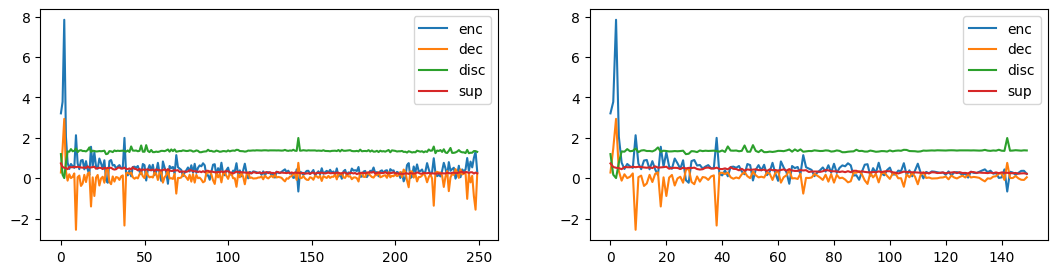

In [12]:
_, axs = plt.subplots( ncols= 2, figsize= (13,3))
df[['enc','dec','disc','sup']].plot( ax= axs[0])
df[['enc','dec','disc','sup']].head(150).plot( ax= axs[1])

<Axes: >

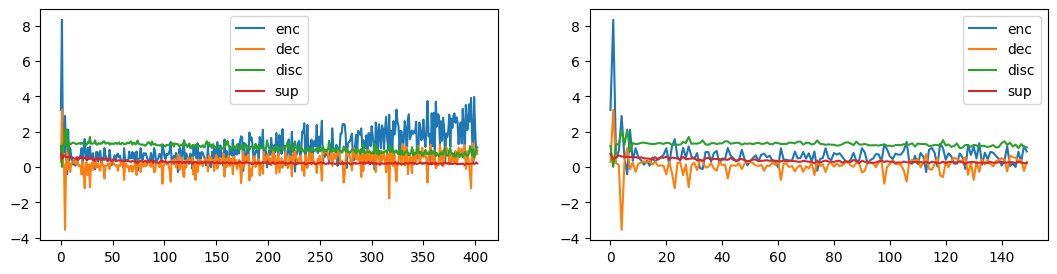

In [37]:
_, axs = plt.subplots( ncols= 2, figsize= (13,3))
df[['enc','dec','disc','sup']].plot( ax= axs[0])
df[['enc','dec','disc','sup']].head(150).plot( ax= axs[1])

### Load model to play with, check matrix

In [71]:
args, model, _ = load_from_checkpoint( res_path)
args.dataset, args.data_dir

Loaded model from ../results/xView_0_fix/bcr_linscm_supce_pretr_norm_flips_res64_batch256_seed51/model250.sav


('xView_0_fix', '../data/xView_0_fix')

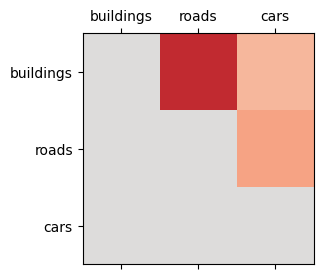

In [14]:
plot_adjacency_matrix( model.prior.A.detach().numpy(), labels_ordered)

Also have data handy - ideally some test data, but for now...

In [72]:
dataset_ = sdd.DatasetLabelled( args.data_dir, 128, args.label_file, args.label_idx, normalize= False)

Loaded labels from ../data/xView_0_fix\labels.csv, total of 8154 entries.
First entry: tif102_x65_y1613.png, with labels [-1 -1 -1]


## Here be dragons...

In [32]:
def split_z( z_pre, num_label):
    return z_pre[ :, :num_label].detach().clone(), z_pre[ :, num_label:].detach().clone()

def join_z( z_label, z_other):
    return torch.cat( [z_label, z_other], dim= 1)

def causal_pass( z_pre, model):
    z_label, z_other = split_z( z_pre, model.num_label)
    return join_z( model.prior( z_label), z_other)

def change_labels( z_label, di_):
    for idx, val in di_.items():
        z_label[ :, idx] = val
    return z_label

def counterfactual_z( z_pre, di_, num_label):
    """
    Set causal node(s) to specific values for decoding to generate counterfactual (no application
    of the causal matrix, to be _counter_factual).
    """
    z_label, z_other = split_z( z_pre, num_label)
    return join_z( change_labels( z_label, di_), z_other)

def intervened_z( z_pre, di_, model):
    """
    Set causal node(s) to specific values + apply the causal matrix to propagate the effect
    of intervention.
    """
    z_label, z_other = split_z( z_pre, num_label)
    z_label = change_labels( z_label, di_)
    return join_z( model.prior( z_label), z_other)
    
def plot_all( x):
    n = len(x)
    _, axs = plt.subplots( ncols= n, figsize= (2*n,2))
    axs = axs.reshape(-1)
    for ii in range(n):
        axs[ii].imshow( dut.to_numpy( sdu.scale_output( x[ii])))
        axs[ii].get_xaxis().set_visible(False)
        axs[ii].get_yaxis().set_visible(False)

In [38]:
latent_ = torch.randn( 4, config_dict['latent_dim'], device= device)
gen_images = model( z= latent_).cpu()
latent_[:,:3]

tensor([[ 0.0166,  0.6515, -0.6668],
        [ 0.1844, -0.0124, -0.2386],
        [-0.3271, -1.2149,  1.0984],
        [ 0.6274,  0.3541,  0.7406]])

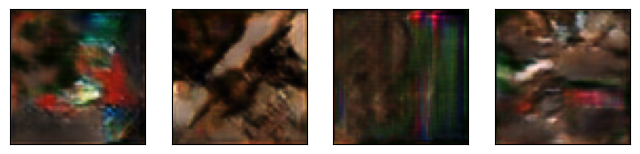

In [39]:
plot_all( gen_images)

In [43]:
latent_[:,:3]

tensor([[ 0.0166,  0.6515, -0.6668],
        [ 0.1844, -0.0124, -0.2386],
        [-0.3271, -1.2149,  1.0984],
        [ 0.6274,  0.3541,  0.7406]])

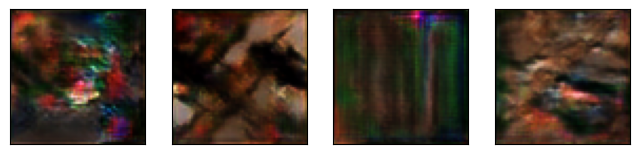

In [42]:
test_no_A = model.decoder( latent_).cpu()
plot_all( test_no_A)

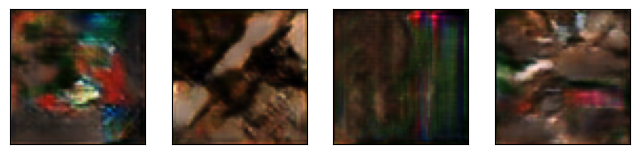

In [44]:
test_A = model.decoder( causal_pass( latent_, model))
plot_all( test_A)

In [65]:
latent_[:,:3]

tensor([[ 0.0166,  0.6515, -0.6668],
        [ 0.1844, -0.0124, -0.2386],
        [-0.3271, -1.2149,  1.0984],
        [ 0.6274,  0.3541,  0.7406]])

In [66]:
latent_cf[:,:3]

tensor([[-10.0000,   0.6515,  -0.6668],
        [-10.0000,  -0.0124,  -0.2386],
        [-10.0000,  -1.2149,   1.0984],
        [-10.0000,   0.3541,   0.7406]])

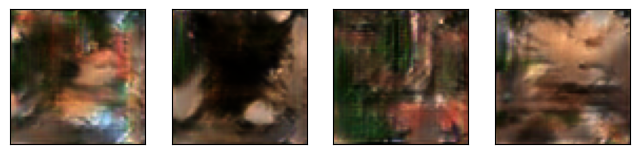

In [68]:
latent_cf = counterfactual_z( latent_, di_= {0:-5,1:20}, num_label= model.num_label)
cf_ims = model.decoder( latent_cf)
plot_all( cf_ims)

In [78]:
data_loader, _ = sdd.make_dataloader( args)

Loaded labels from ../data/xView_0_fix\labels.csv, total of 8154 entries.
First entry: tif102_x65_y1613.png, with labels [-1 -1 -1]


In [80]:
images, labels, names = sdd.get_batch_no( data_loader, 0)

In batch 0 there are 71 supervised.


In [81]:
len(images)

256

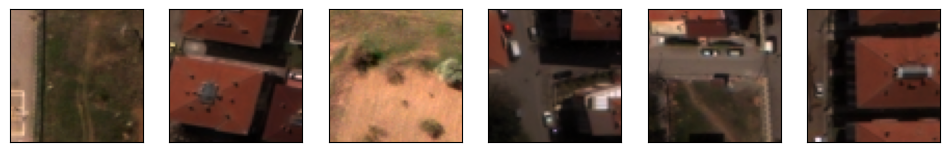

In [102]:
plot_all( images[6:12])

In [103]:
z_encoded = model.encode( images[6:12])
z_encoded[:,:3]

tensor([[ -0.8476,  -3.1708,  -9.2073],
        [  0.4965,   0.2253,  -1.7046],
        [ -0.4769,  -2.9849, -10.6192],
        [  0.9493,   2.4089,   5.4668],
        [  0.8977,   1.7132,   4.6442],
        [  1.4363,   3.9652,  13.3902]], grad_fn=<SliceBackward0>)

In [104]:
ims_decoded = model.decoder( z_encoded)

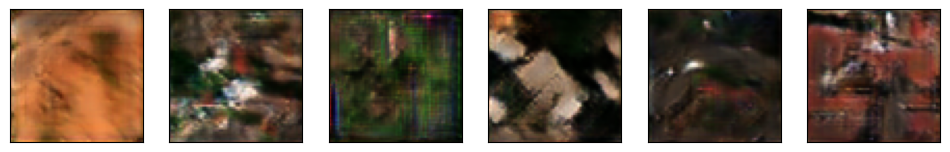

In [105]:
plot_all( ims_decoded)

In [111]:
which = 0
torch.sqrt( ( ( ims_decoded[which].detach() - images[which].detach() )**2 ).mean() )

tensor(0.2762)